## Consumer Sentiment Analysis of Apple and Google Products Using NLP

**Author:** Diana Byegon
**Project type:** Multiclass text classification  
**Dataset:** CrowdFlower Twitter sentiment dataset on Apple and Google products  
**Primary technique:** Natural Language Processing  
**Advanced components:** feature engineering, pipelines, cross-validation, model comparison, confusion matrices, and model interpretability

# 1. Business Understanding

## 1.1 Business Context

Social media is one of the fastest channels through which customers express opinions about technology products. During product launches, conferences, updates, and service issues, consumers often share reactions publicly on Twitter. For companies such as Apple and Google, these tweets can contain valuable signals about customer satisfaction, product perception, and potential customer experience issues.

However, manually reviewing thousands of tweets is slow, expensive, and difficult to scale. Product marketing and customer experience teams need a way to quickly separate positive, negative, and neutral feedback so they can understand public perception and respond to emerging concerns.

## 1.2 Business Problem

Product marketing and customer experience teams need timely insights into how customers perceive Apple and Google products. While social media contains a wealth of customer feedback, manually reviewing thousands of tweets is time-consuming, resource-intensive, and impractical. Without an automated sentiment analysis system, organizations may struggle to:

(i) Detect negative customer sentiment early.

(ii) Identify emerging product issues.

(iii) Measure public reaction to product launches and marketing campaigns.

(iv) Understand the key factors driving customer satisfaction and dissatisfaction.

This project aims to address this challenge by developing a machine learning model capable of automatically classifying the sentiment expressed in tweets related to Apple and Google products.

## 1.3 Stakeholders

**Primary stakeholders:** Product Marketing Managers at Apple and Google.  
They are responsible for tracking customer perception, measuring campaign and launch reception, and understanding how customers talk about products.

**Secondary stakeholders:** Customer Experience Teams.  
They can use sentiment classification to identify negative tweets that may require follow-up or deeper investigation.

**Strategic stakeholders:** Brand and Communications Teams.  
They can use sentiment trends to understand public reaction and protect brand reputation.

## 1.4 Project Goal

The goal of this project is to develop a Natural Language Processing (NLP) model capable of automatically classifying sentiment expressed in tweets related to Apple and Google products.

The model will categorize tweets according to their sentiment and provide insights into the language and factors that influence customer opinions.

# 1.5 Business Questions

1. **What overall sentiment are customers expressing toward Apple and Google products on Twitter?**  
   
2. **Can tweet content be used to accurately identify customer sentiment?**  
   
3. **What words and phrases most strongly influence positive and negative customer sentiment?**  
   

## 1.6 Success Metrics

**Business success:**  
The project is successful if it creates a model that helps stakeholders monitor sentiment more efficiently and provides actionable insight into customer language.

**Technical success:**  
The primary metric is **weighted F1-score** because the dataset contains imbalanced sentiment classes. Weighted F1 balances precision and recall while accounting for class size.

Secondary metrics include accuracy, precision, recall, and confusion matrix results.

# 2. Data Understanding
## 2.1 Data Source

The dataset used in this project is the Twitter Sentiment Dataset, originally collected through CrowdFlower and made available through Data.world. The dataset contains tweets discussing Apple and Google products and includes manually assigned sentiment labels.

Human annotators reviewed each tweet and classified the sentiment expressed toward a brand or product.This dataset is appropriate for the project because it contains real-world customer opinions that can be used to train a machine learning model


## 2.2 Data Overview
### 2.2.1 Importing Libraries

Before exploring the dataset, the necessary Python libraries must be imported to support data manipulation, visualization, and exploratory analysis.

In [11]:
# data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import string
from collections import Counter

# Machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option('display.max_colwidth', 200)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

### 2.2.2 Loading the Dataset

In [7]:
df = pd.read_csv( r'Data\judge-1377884607_tweet_product_company.csv',encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",iPhone,Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Google,Positive emotion


  
The dataset consists of three main variable; tweet text, the product or brand the tweet is directed at, and a sentiment label. The tweet text will be the main predictor, while the sentiment label will be the target variable for supervised learning.

### 2.2.3 Data shape
Understanding the size of the dataset helps determine whether sufficient observations are available for model training and evaluation.

In [ ]:
# Dimensions
df.shape

(9093, 3)

The dataset contains 9,093 rows and 3 columns.

Rows represent individual tweets.
Columns represent tweet features and sentiment labels.

With over 9,000 observations, the dataset provides a sufficiently large sample of customer opinions to support machine learning analysis.

### 2.2.4 Data Information
Examining the dataset structure helps identify data types and missing values that may require attention during data cleaning.


In [10]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


The dataset contains both complete and incomplete fields. While sentiment labels are fully populated, some observations contain missing product information.

Missing product information may limit product-level analysis but does not prevent sentiment classification because the primary predictor is tweet text.

### 2.2.5 Descriptive Statistics
Descriptive statistics provide a summary of the dataset and help identify potential data quality issues.

In [12]:
# Summary Statistics
df.describe(include='all')

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw,iPad,No emotion toward brand or product
freq,5,946,5389


The dataset contains tweet text, the product or brand the tweet is directed at, and a sentiment label. The tweet text will be the main predictor, while the sentiment label will be the target variable for supervised learning.

## 2.3 Data Quality Assessment
Assessing the overall quality of the dataset helps identify missing values, duplicate records, and potential issues that may affect model performance and interpretation.

Understanding these issues early allows us to develop an appropriate data cleaning strategy while maintaining transparency and reproducibility throughout the project.

### 2.3.1 Missing Values
Missing values can reduce data quality and potentially impact downstream analysis and model performance. This step identifies the extent of missing information within each feature.

In [21]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_values

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

The output shows the number of missing observations in each feature.

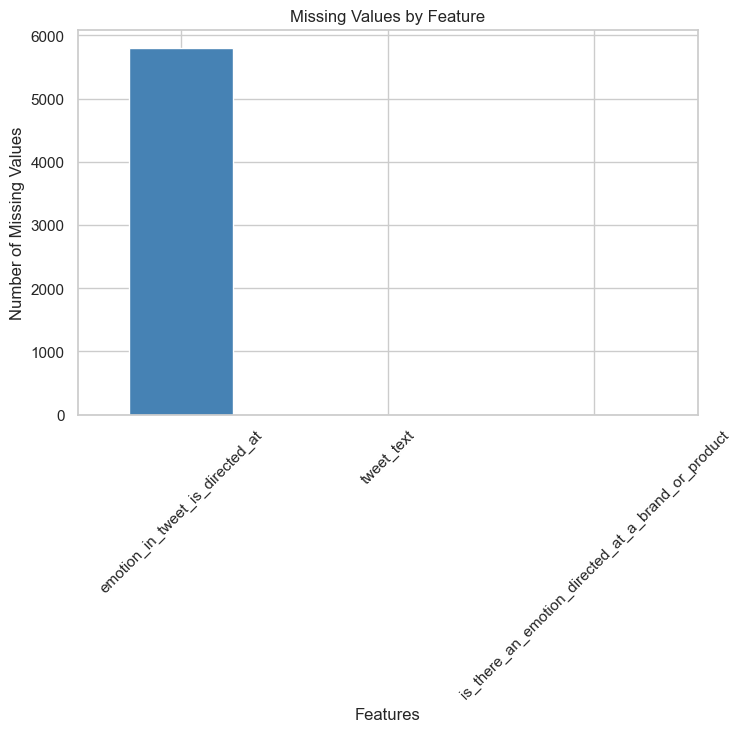

In [19]:
# Visualize missing values

plt.figure(figsize=(8,5))

missing_values.sort_values(ascending=False).plot(
    kind='bar',
    color='steelblue'
)

plt.title('Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')

plt.xticks(rotation=45)

plt.show()

The visualization highlights that the majority of missing values occur in the product-related feature, while the tweet text and sentiment label fields contain little to no missing data.

Since sentiment labels represent the target variable, missing values in this field would significantly reduce the dataset's usefulness for supervised learning. Missing product information may affect product-level analysis but is less critical for sentiment classification because tweet text remains the primary predictor.

### 2.3.2 Dulplicates

Duplicate observations can bias model training and inflate performance metrics if not identified and addressed.

In [23]:
# Check for duplicate records

duplicates = df.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 22


Duplicate tweets may cause the model to learn repetitive patterns that do not accurately represent real-world customer sentiment. Removing duplicates helps improve the reliability of the analysis.

### 2.3.3 Data Type
Verifying data types ensures that each variable is stored in an appropriate format for analysis and modeling.

In [ ]:
# data types

df.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

All variables are currently stored as object (string) data types, which is expected because the dataset consists primarily of textual information.

### 2.3.4 Data Quality Summary

The data quality assessment revealed several important observations:

(i) The dataset contains 9,093 tweets.

(ii) The sentiment label column contains no missing values, making it suitable for supervised learning.

(iii) The product-related feature contains a substantial number of missing values.

(iv) The tweet text feature contains very few missing observations.

(v) Duplicate records may exist and should be addressed during data cleaning.

(vi) All variables are stored as text-based features.

**Implications for the Project**

The dataset remains highly suitable for sentiment classification because the target variable is complete and the tweet text field is largely intact.

The primary data quality challenge involves missing product information. However, since the objective of the project is to classify sentiment based on tweet content, this issue is not expected to significantly impact model performance.

## 2.3.5 Dataset Limitations

The dataset is useful for a proof-of-concept NLP sentiment classifier, but it has limitations:

 **Class imbalance:** Negative and unclear tweets are much less common than neutral/no-emotion tweets.

 **Missing product labels:** Many tweets do not specify the product or brand they are directed at.

 **Historical Twitter data:** Language patterns may differ from current social media behavior.

 **Human labeling subjectivity:** Sentiment labels depend on human raters and may include ambiguity.
 
 **Short text complexity:** Tweets are brief and may contain sarcasm, abbreviations, hashtags, and informal language.